In [ ]:
%pip install -r ../../requirements.txt -q
%pip install pyvirtualdisplay


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---
# Gym Hopper

The Hopper is a one-legged 2D robot simulated in MuJoCo. The task is to make it hop forward as fast as possible without falling over.


**Test a random policy on the Gym Hopper environment**


Play around with this code to get familiar with the
Hopper environment.

For example, 
- what happens if you don't reset the environment even after the episode is over?
- When exactly is the episode over?
- What is an action here?

In [2]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Suppress the v4 deprecation warning — we use v4 to match project template
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

SEED = 42
print('gymnasium version:', gym.__version__)
print('numpy version:', np.__version__)

gymnasium version: 1.2.3
numpy version: 2.4.5


## Create the Environment & Inspect Spaces

In [3]:
env = gym.make('Hopper-v4', render_mode='rgb_array')

print('State space:', env.unwrapped.observation_space)  # state-space
print('Action space:', env.action_space)  # action-space

State space: Box(-inf, inf, (11,), float64)
Action space: Box(-1.0, 1.0, (3,), float32)


In [4]:
obs, info = env.reset(seed=SEED)

print('=' * 100)
print('OBSERVATION SPACE')
print('=' * 100)
print(f'  Type  : {env.observation_space}')
print(f'  Shape : {env.observation_space.shape}  → {env.observation_space.shape[0]}D vector')
print(f'  dtype : {env.observation_space.dtype}')
print(f'  low   : {env.observation_space.low[:4]} ... (all -inf)')
print(f'  high  : {env.observation_space.high[:4]} ... (all +inf)')

print()
print('=' * 100)
print('ACTION SPACE')
print('=' * 100)
print(f'  Type  : {env.action_space}')
print(f'  Shape : {env.action_space.shape}  → {env.action_space.shape[0]} continuous torques')
print(f'  dtype : {env.action_space.dtype}')
print(f'  low   : {env.action_space.low}  (clipped at -1)')
print(f'  high  : {env.action_space.high}  (clipped at +1)')

env.close()

OBSERVATION SPACE
  Type  : Box(-inf, inf, (11,), float64)
  Shape : (11,)  → 11D vector
  dtype : float64
  low   : [-inf -inf -inf -inf] ... (all -inf)
  high  : [inf inf inf inf] ... (all +inf)

ACTION SPACE
  Type  : Box(-1.0, 1.0, (3,), float32)
  Shape : (3,)  → 3 continuous torques
  dtype : float32
  low   : [-1. -1. -1.]  (clipped at -1)
  high  : [1. 1. 1.]  (clipped at +1)


### What is an action here?


In the Gymnasium **Hopper** environment, the action space is **continuous** and has a dimension of **3**.

It represents the specific torques applied to the three internal hinge joints of the one-legged robot to control its propulsion and balance.

#### Mathematical Structure

The action space is formally defined as a bounded continuous space:


$$\text{Action Space} \in [-1.0, 1.0]^3$$

This means every action sent to the environment at each timestep is a 3-dimensional vector of floating-point numbers, where each value is clamped between $-1.0$ and $1.0$ (representing normalized torque).

---

#### The 3 Actuator Channels

* **Action `[0]` (Thigh/Hip Hinge):** Controls the torque at the joint connecting the main torso to the thigh. It dictates forward and backward hip swinging.
* **Action `[1]` (Leg/Knee Hinge):** Controls the torque at the knee joint connecting the thigh to the lower leg. Crucial for flexion and extension to store and release energy for jumping.
* **Action `[2]` (Foot/Ankle Hinge):** Controls the torque at the ankle joint connecting the lower leg to the foot piece. Essential for stabilizing the landing and providing the final push-off drive.


### When exactly is the episode over?

In modern Gymnasium, the environment signals that an episode is over using two separate flags: `terminated` and `truncated`. 

Here is exactly how the Hopper environment figures out when to trigger them:

#### 1. `terminated` (The Failure Condition)
This flag turns `True` when the robot reaches a specific physical state that the creators defined as a "failure" or "success". 

For **Hopper-v4**, the environment checks if the robot is "healthy" at every single step. The hopper is considered **unhealthy** (and the episode terminates) if *any* of the following happen:
*   **It falls too low:** The z-coordinate (height of its main torso) drops below `0.7` meters.
*   **It leans too far:** The absolute pitch angle of its torso exceeds `0.2` radians (about 11.5 degrees). If it leans forward or backward beyond this, it is considered unrecoverable.
*   **It explodes:** If any of the physics state variables (like joint velocities) become infinite or NaN (which can happen if the physics simulator bugs out from extreme forces).

The moment any of these constraints are violated, `terminated` is returned as `True`.

#### 2. `truncated` (The Time Limit Condition)
This flag turns `True` if the agent successfully stays alive, but simply runs out of time. 

Reinforcement Learning environments usually impose a maximum step limit so the agent doesn't get stuck in an infinite loop (and so it is forced to collect rewards efficiently). For Hopper, the default `max_episode_steps` is **1000**. 

If the Hopper survives for 1000 steps without violating any of the "healthy" conditions above, `truncated` becomes `True`, signaling that the episode is ending purely because time is up.

In [5]:
from IPython import display as ipythondisplay
from IPython.display import HTML
import matplotlib.pyplot as plt
from IPython.display import clear_output

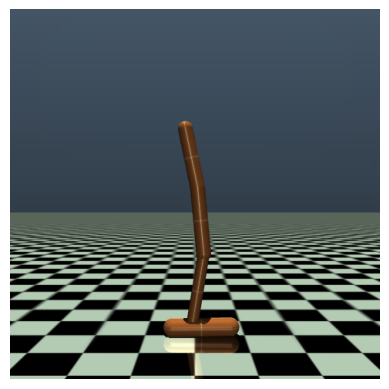

Episode terminated at step: 12 because pitch angle exceeded |0.2| rad
Final Observation: [ 1.19181856 -0.20494712 -0.11202766 -0.25560761  0.17461178 -0.18769537
 -0.81161942 -3.25933158 -2.46022457 -2.90759256  4.44592615]


In [6]:
env = gym.make('Hopper-v4', render_mode='rgb_array')

heights = []
pitches = []
steps = []

reason = "Unknown"

# FIX 1: Change 'observation' to 'obs'
obs, _ = env.reset(seed=SEED)

for step_count in range(200):
    
    # Record the observation before taking the action
    heights.append(obs[0])
    pitches.append(obs[1])
    steps.append(step_count)
    
    action = env.action_space.sample()
    
    try:
        obs, reward, terminated, truncated, info = env.step(action)
    except Exception as e:
        print(f"Simulation stopped early: {e}")
        break
        
    frame = env.render()
    
    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis('off')
    plt.show()
    
    if terminated:
        # Record the final "terminal" observation
        heights.append(obs[0])
        pitches.append(obs[1])
        # FIX 2: We took a step, so this represents the next timestep
        steps.append(step_count + 1) 

        if not np.isfinite(obs).all():
            reason = "of physics Explosion (NaN/Inf)"
        elif obs[0] < 0.7:
            reason = "height dropped below 0.7m"
        elif abs(obs[1]) > 0.2:
            reason = "pitch angle exceeded |0.2| rad"
        else:
            reason = "of other/out of bounds state"
        
        print(f"Episode terminated at step: {step_count} because {reason}")
        # FIX 3: Change observation to obs here so it prints the final state
        print(f"Final Observation: {obs}") 
        
        break

    if truncated: 
        heights.append(obs[0])
        pitches.append(obs[1])
        steps.append(step_count + 1)
        reason = "(Time limit of 1000 steps reached)"
        print(f'Episode TRUNCATED at step {step_count} {reason}.')
        break
             
env.close()


Episode ended at step 12.
Termination Reason: pitch angle exceeded |0.2| rad
Final Height: 1.1918, Final Pitch: -0.2049


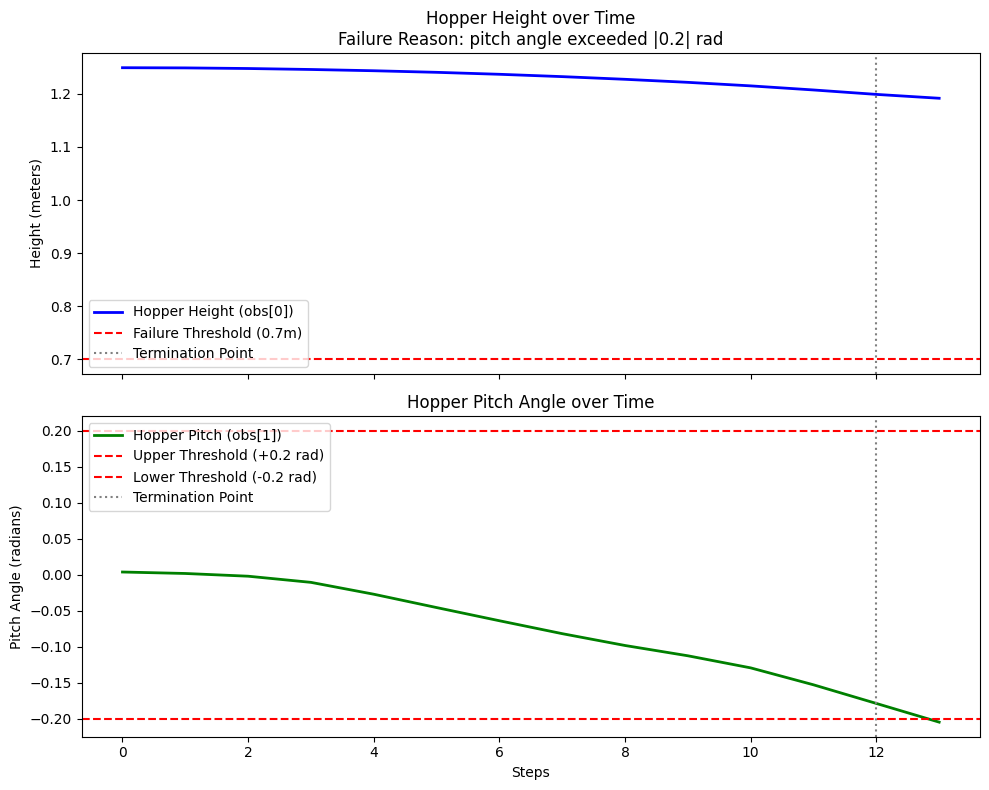

In [7]:
print(f"Episode ended at step {step_count}.")
print(f"Termination Reason: {reason}")
print(f"Final Height: {obs[0]:.4f}, Final Pitch: {obs[1]:.4f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 1. Height Plot
ax1.plot(steps, heights, label="Hopper Height (obs[0])", color='blue', linewidth=2)
ax1.axhline(y=0.7, color='red', linestyle='--', label="Failure Threshold (0.7m)")
ax1.axvline(x=step_count, color='gray', linestyle=':', label="Termination Point")
ax1.set_ylabel("Height (meters)")
ax1.set_title(f"Hopper Height over Time\nFailure Reason: {reason}")
ax1.legend(loc="lower left")

# Annotate if height was the failure
if "Height" in reason:
    ax1.annotate('Dropped too low!', xy=(step_count, obs[0]), xytext=(step_count-15, obs[0]+0.3),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10, color='red', fontweight='bold')

# 2. Pitch Angle Plot
ax2.plot(steps, pitches, label="Hopper Pitch (obs[1])", color='green', linewidth=2)
ax2.axhline(y=0.2, color='red', linestyle='--', label="Upper Threshold (+0.2 rad)")
ax2.axhline(y=-0.2, color='red', linestyle='--', label="Lower Threshold (-0.2 rad)")
ax2.axvline(x=step_count, color='gray', linestyle=':', label="Termination Point")
ax2.set_xlabel("Steps")
ax2.set_ylabel("Pitch Angle (radians)")
ax2.set_title("Hopper Pitch Angle over Time")
ax2.legend(loc="upper left")

# Annotate if pitch was the failure
if "Pitch" in reason:
    # Place text slightly above or below the point depending on if it went positive or negative
    text_y = 0 if obs[1] > 0 else 0

plt.tight_layout()
plt.show()

### What happens if you don't reset the environment after the episode is over?

The pre-defined termination rules help us terminate a learning instance when needed. When we choose to continue the loop, instead of breaking, we discover important findings about the environment and behavior:

#### Physics Doesn't "Stop"
At its core, the Hopper environment is just a physics simulation (running in MuJoCo). The concepts of "episodes" or being "done" are entirely artificial constructs created for the Reinforcement Learning agent. When the Hopper falls over, physics doesn't magically freeze. If you send another action, the physics engine will happily apply that torque to the motors of a robot that is currently lying flat on the floor! 

#### The Agent Will Learn to Wiggle on the Floor
If you don't use `env.reset()` when the episode is over, your RL agent will continue taking steps while lying on the ground. Because it might still get tiny amounts of reward for moving its joints (or large negative penalties for being fallen), it will start learning a policy for what to do while lying down, rather than learning how to hop. This completely breaks the training process.

*When we render those extra steps, we literally just see the hopper flopping around helplessly on the ground!*

In [14]:
env = gym.make('Hopper-v4', render_mode='rgb_array')
observation, info = env.reset(seed=SEED)
done = False
while not done:
    observation, reward, terminated, truncated, info = env.step(env.action_space.sample())
    done = terminated or truncated

print('Episode is over. Taking one more step without resetting...')
try:
    env.step(env.action_space.sample())
    print('Step succeeded!')
except Exception as e:
    print(f'Error caught: {type(e).__name__} - {e}')

env.close()

Episode is over. Taking one more step without resetting...
Step succeeded!


The try/except wasn't catching anything — the step succeeded, and what we actually demonstrated is the silent-failure case: Gymnasium happily lets you keep calling step() past a terminated=True, and the physics engine just continues integrating from the fallen pose. So the hopper wriggles around on the ground accumulating nonsense reward. 

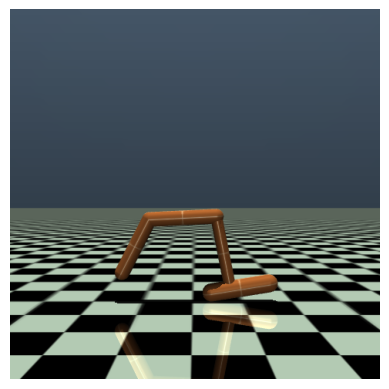

In [15]:
env = gym.make('Hopper-v4', render_mode='rgb_array')
observation, _ = env.reset(seed=SEED)
for i in range(200):
    action = env.action_space.sample()
    
    # Safely take a step. If the environment strictly blocks us 
    # from stepping after it is done, it will catch the error here.
    try:
        observation, reward, terminated, truncated, info = env.step(action)
    except Exception as e:
        print(f"Simulation stopped early: {e}")
        break
        
    frame = env.render()
    
    # Clear the previous output and show the new frame
    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis('off')
    plt.show()
    
    # If the episode ends, we ignore it and continue the loop!
    if terminated:
        #break
        continue 
    if truncated: 
        print(f'Episode TRUNCATED at step {i} (Time limit of 1000 steps reached).')
        break
             
env.close()

### What Does Each Observation Dimension Mean?

The Hopper observation is an **11-dimensional** vector. The x-position is **excluded** (it would make the state non-Markovian for a translation-invariant policy).

| Index | Variable | Physical Meaning |
|-------|----------|------------------|
| 0 | z-position | Height of the torso |
| 1 | rooty | Angle of torso (pitch) |
| 2 | thigh_joint | Angle of thigh relative to torso |
| 3 | leg_joint | Angle of shin relative to thigh |
| 4 | foot_joint | Angle of foot relative to shin |
| 5 | x-velocity | Forward speed |
| 6 | z-velocity | Vertical speed |
| 7 | rooty-velocity | Angular velocity of torso |
| 8 | thigh-velocity | Angular velocity of thigh joint |
| 9 | leg-velocity | Angular velocity of leg joint |
| 10 | foot-velocity | Angular velocity of foot joint |

In [10]:
env = gym.make('Hopper-v4', render_mode='rgb_array')

obs, info = env.reset(seed=SEED)

obs_labels = [
    'z-pos (torso height)',
    'rooty (torso pitch)',
    'thigh_joint angle',
    'leg_joint angle',
    'foot_joint angle',
    'x-velocity (forward speed)',
    'z-velocity (vertical speed)',
    'rooty-velocity',
    'thigh-velocity',
    'leg-velocity',
    'foot-velocity',
]

print('Initial observation (seed=42):')
print('-' * 45)
for i, (val, label) in enumerate(zip(obs, obs_labels)):
    print(f'  obs[{i:2d}]  {val:+.6f}   {label}')

print()
print('Note: All values are near zero at reset — the hopper starts upright & still.')
print(f'  Torso height at reset: {obs[0]:.4f} m  (≈ 1.25 m, stable upright position)')

Initial observation (seed=42):
---------------------------------------------
  obs[ 0]  +1.249389   z-pos (torso height)
  obs[ 1]  +0.003586   rooty (torso pitch)
  obs[ 2]  +0.001974   thigh_joint angle
  obs[ 3]  -0.004058   leg_joint angle
  obs[ 4]  +0.004756   foot_joint angle
  obs[ 5]  +0.002611   x-velocity (forward speed)
  obs[ 6]  +0.002861   z-velocity (vertical speed)
  obs[ 7]  -0.003719   rooty-velocity
  obs[ 8]  -0.000496   thigh-velocity
  obs[ 9]  -0.001292   leg-velocity
  obs[10]  +0.004268   foot-velocity

Note: All values are near zero at reset — the hopper starts upright & still.
  Torso height at reset: 1.2494 m  (≈ 1.25 m, stable upright position)


#### MuJoCo Body Masses (Link Masses)

These are the **physical parameters** inside the MuJoCo XML model. When we implement domain randomization in Part 2, we will perturb these values.

In [11]:
model = env.unwrapped.model

print('=' * 50)
print('MUJOCO MODEL — BODY MASSES')
print('=' * 50)

print("=== SOURCE (DEFAULT) VARIANTS ===")
body_data = []
for i in range(model.nbody):
    name = model.body(i).name
    mass = float(model.body_mass[i])
    body_data.append((i, name, mass))
    if name != 'world':  # skip massless world body
        print(f'  body[{i}]  name={name!r:15s}  mass={mass:.4f} kg')

total_mass = sum(m for _, n, m in body_data if n != 'world')
print(f'\n  Total robot mass: {total_mass:.4f} kg')

print()
print('=' * 50)
print('MUJOCO MODEL — JOINTS')
print('=' * 50)
for i in range(model.njnt):
    name = model.joint(i).name
    jtype = model.jnt_type[i]  # 0=free, 1=ball, 2=slide, 3=hinge
    jtype_str = {0: 'free', 1: 'ball', 2: 'slide', 3: 'hinge'}.get(jtype, '?')
    print(f'  joint[{i}]  name={name!r:15s}  type={jtype_str}')

print()
print('Note: rootx (slide) = forward translation. rootz (slide) = height.')
print('These two are NOT actuated — only the 3 hinge joints are.')

# Print the new Target masses
for i in range(model.nbody):
    body_name = model.body(i).name
    mass = model.body_mass[i]
    if body_name != 'world':
        print(f"Body: {body_name:<10} | Mass: {mass:.4f} kg")
env.close()

MUJOCO MODEL — BODY MASSES
=== SOURCE (DEFAULT) VARIANTS ===
  body[1]  name='torso'          mass=3.6652 kg
  body[2]  name='thigh'          mass=4.0579 kg
  body[3]  name='leg'            mass=2.7814 kg
  body[4]  name='foot'           mass=5.3156 kg

  Total robot mass: 15.8200 kg

MUJOCO MODEL — JOINTS
  joint[0]  name='rootx'          type=slide
  joint[1]  name='rootz'          type=slide
  joint[2]  name='rooty'          type=hinge
  joint[3]  name='thigh_joint'    type=hinge
  joint[4]  name='leg_joint'      type=hinge
  joint[5]  name='foot_joint'     type=hinge

Note: rootx (slide) = forward translation. rootz (slide) = height.
These two are NOT actuated — only the 3 hinge joints are.
Body: torso      | Mass: 3.6652 kg
Body: thigh      | Mass: 4.0579 kg
Body: leg        | Mass: 2.7814 kg
Body: foot       | Mass: 5.3156 kg


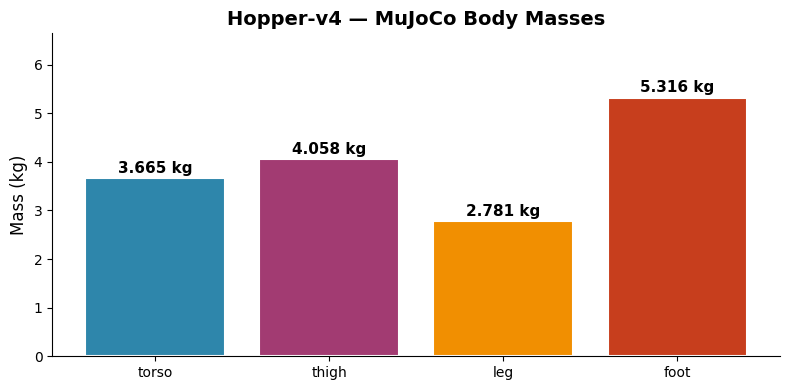

Saved: hopper_body_masses.png


In [12]:
# Visualise body masses as a bar chart
bodies = [(n, m) for _, n, m in body_data if n != 'world']
names = [b[0] for b in bodies]
masses = [b[1] for b in bodies]

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, masses, color=colors, edgecolor='white', linewidth=1.5)
ax.set_ylabel('Mass (kg)', fontsize=12)
ax.set_title('Hopper-v4 — MuJoCo Body Masses', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(masses) * 1.25)

for bar, mass in zip(bars, masses):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
            f'{mass:.3f} kg', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('hopper_body_masses.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hopper_body_masses.png')

## Reward Structure and Termination

The Hopper reward at each step is composed of three terms:

$$r_t = r_{\text{forward}} + r_{\text{alive}} - r_{\text{control}}$$

- **$r_{\text{forward}}$** = x-velocity (how fast the hopper moves forward)
- **$r_{\text{alive}}$** = constant `+1` at every non-terminal step
- **$r_{\text{control}}$** = 0.001 × ||action||² (small penalty for large torques)

**Termination** occurs when:
- Torso height < 0.7 m (fell over)
- Torso angle |rooty| > 0.2 rad (too tilted)
- Any observation dimension is not finite

In [13]:
# Simulate a short random-policy episode and log reward components
env = gym.make('Hopper-v4')
obs, info = env.reset(seed=SEED)

rewards, x_velocities, heights = [], [], []
step = 0
rng = np.random.default_rng(SEED)

while True:
    action = rng.uniform(-1, 1, size=3).astype(np.float32)
    obs, reward, terminated, truncated, info = env.step(action)
    rewards.append(reward)
    x_velocities.append(info['x_velocity'])
    heights.append(obs[0])  # z-position = obs[0]
    step += 1
    if terminated or truncated:
        print(f'Episode ended at step {step}')
        print(f'  Terminated (fell): {terminated}')
        print(f'  Truncated (timeout): {truncated}')
        break

env.close()

print(f'Total steps: {step}')
print(f'Total reward (undiscounted): {sum(rewards):.3f}')
print(f'Mean reward/step: {np.mean(rewards):.3f}')
print(f'Mean x-velocity: {np.mean(x_velocities):.4f} m/s')
print(f'Min torso height: {min(heights):.4f} m')

Episode ended at step 35
  Terminated (fell): True
  Truncated (timeout): False
Total steps: 35
Total reward (undiscounted): 36.335
Mean reward/step: 1.038
Mean x-velocity: 0.0391 m/s
Min torso height: 1.2069 m
